# Minimal Product: Task Integration Demand & Information Geometry
**Hypothesis:** Tasks requiring the integration of multiple streams (Context) will force the network to encode information synergistically. Simple accumulation tasks (Perceptual) will be solved redundantly. This effect should peak exactly at the end of the stimulus period.

We test this by training both an Elman RNN and a CTRNN to compare how temporal architectures affect the `gaussian_pid` structure.

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import neurogym as ngym

import os
import sys
sys.path.append('../') # Ensure we can see the src folder
from src.models.ctrnn import CTRNN
from src.analysis.RNN import ElmanRNN
from src.analysis.gaussian_pid import gaussian_pid_rnn
from src.tasks.neurogym_wrapper import create_dataset_generator

In [31]:
# --- GLOBAL CONFIGURATION ---
HIDDEN_SIZE = 20
RESULTS_DIR = '../results/model_weights'
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. The Architectures
We define both the Elman RNN and the CTRNN. We configure both to use `batch_first=True` for easier tensor slicing, and output the full sequence of hidden states for the PID analysis.

In [20]:
class WrappedCTRNN(nn.Module):
    def __init__(self, input_dim, hidden_size):
        super().__init__()
        # Use the existing CTRNN
        self.model = CTRNN(input_size=input_dim, hidden_size=hidden_size, output_size=3)
        
    def forward(self, x):
        # CTRNN expects (Batch, Seq, Dim). 
        # We grab outputs and hidden_states, ignoring predictions.
        outputs, _, hidden_states = self.model(x, return_dynamics=True)
        return outputs, hidden_states

class WrappedElman(nn.Module):
    def __init__(self, input_dim, hidden_size):
        super().__init__()
        # Use teammate's ElmanRNN, override to 80 units
        self.model = ElmanRNN(dim=input_dim, hidden_dim=hidden_size)
        # Teammate's code hardcoded output=input_dim. We overwrite it to 3 for our task classes.
        self.model.readout = nn.Linear(hidden_size, 3) 
        
    def forward(self, x):
        # x is (Batch, Seq, Dim). 
        # Teammate's ElmanRNN forward() assumes batch=1 and seq_first.
        # We bypass their forward() and just call their internal layers directly to support batching.
        x_seq_first = x.transpose(0, 1) # Convert to (Seq, Batch, Dim)
        
        h_seq, _ = self.model.rnn(x_seq_first) 
        outputs = self.model.readout(h_seq)
        
        # Transpose back to (Batch, Seq, Features) for the training loop
        return outputs.transpose(0, 1), h_seq.transpose(0, 1)

### 2. The Data Wrapper & Masked Loss
We implement the explicit context fix for NeuroGym and write a custom loss function that only penalizes the network during the decision period (ignoring the fixation targets of `0`).

In [21]:
def masked_cross_entropy(outputs, targets):
    """Computes loss only on the decision timesteps (where target != 0)"""
    mask = targets != 0
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(outputs.device)
    
    # Flatten everything and apply the mask
    masked_outputs = outputs[mask]
    masked_targets = targets[mask]
    
    return F.cross_entropy(masked_outputs, masked_targets)

### 3. The Training Loop
We will train 4 total models: Elman vs. CTRNN on Perceptual vs. Context. We train for 500 batches to get a functional Proof of Concept.

In [22]:
tasks = ['PerceptualDecisionMaking-v0', 'ContextDecisionMaking-v0']
models = {'Elman': WrappedElman, 'CTRNN': WrappedCTRNN}

trained_networks = {}

for task in tasks:
    input_dim = 3 if 'Perceptual' in task else 7

    # 1. Create the dataset ONCE per task
    dataset = create_dataset_generator(task)
    
    for model_name, ModelClass in models.items():
        key = f"{model_name}_{task}"
        print(f"\nTraining {key}...")

        model = ModelClass(input_dim, hidden_size=HIDDEN_SIZE).to(device)
        optimizer = optim.Adam(model.parameters(), lr=2e-3)
        
        for i in range(500):
            # 2. Pull from the existing dataset
            inputs_np, targets_np = dataset()
            
            # 3. Push to GPU and swap axes for batch_first
            inputs = torch.from_numpy(inputs_np).float().transpose(0, 1).to(device)
            targets = torch.from_numpy(targets_np).long().transpose(0, 1).to(device)
            
            optimizer.zero_grad()
            
            outputs, _ = model(inputs)
            loss = masked_cross_entropy(outputs, targets)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            if (i+1) % 100 == 0:
                print(f"  Batch {i+1} | Loss: {loss.item():.4f}")
                
        # Save the trained model weights to the results folder
        save_path = os.path.join(RESULTS_DIR, f"{key}_h{HIDDEN_SIZE}.pt")
        torch.save(model.state_dict(), save_path)
        print(f"  -> Saved to {save_path}")
        
        trained_networks[key] = model


Training Elman_PerceptualDecisionMaking-v0...
  Batch 100 | Loss: 0.7021
  Batch 200 | Loss: 0.6930
  Batch 300 | Loss: 0.7042
  Batch 400 | Loss: 0.6916
  Batch 500 | Loss: 0.4341
  -> Saved to ../results/model_weights\Elman_PerceptualDecisionMaking-v0_h20.pt

Training CTRNN_PerceptualDecisionMaking-v0...
  Batch 100 | Loss: 0.2739
  Batch 200 | Loss: 0.2622
  Batch 300 | Loss: 0.1831
  Batch 400 | Loss: 0.5031
  Batch 500 | Loss: 0.3681
  -> Saved to ../results/model_weights\CTRNN_PerceptualDecisionMaking-v0_h20.pt

Training Elman_ContextDecisionMaking-v0...
  Batch 100 | Loss: 0.7017
  Batch 200 | Loss: 0.6773
  Batch 300 | Loss: 0.6888
  Batch 400 | Loss: 0.6927
  Batch 500 | Loss: 0.6929
  -> Saved to ../results/model_weights\Elman_ContextDecisionMaking-v0_h20.pt

Training CTRNN_ContextDecisionMaking-v0...
  Batch 100 | Loss: 0.5143
  Batch 200 | Loss: 0.4428
  Batch 300 | Loss: 0.3608
  Batch 400 | Loss: 0.1354
  Batch 500 | Loss: 0.1301
  -> Saved to ../results/model_weights\CT

### 4. Time-Resolved PID Analysis
We generate a large testing ensemble (200 trials), run them through the trained networks without updating weights, and calculate the Gaussian PID at *every single timestep*. We use the final trial choice as the target variable for the PID.

In [25]:
def get_aligned_test_batch(task_name, batch_size=200, dt=20):
    """Generates an ensemble of isolated, perfectly time-aligned trials."""
    # Force fixed deterministic timing for the PID evaluation
    timing = {
        'fixation': 200,   # 10 timesteps
        'stimulus': 1000,  # 50 timesteps
        'delay': 0,
        'decision': 100    # 5 timesteps
    }
    env_kwargs = {'dt': dt, 'timing': timing}
    env = ngym.make(task_name, **env_kwargs)
    
    inputs_list, targets_list = [], []
    
    for _ in range(batch_size):
        env.reset()
        obs_trial, act_trial = [], []
        while True:
            action = env.action_space.sample()
            step_returns = env.step(action)
            if len(step_returns) == 5:
                obs, _, _, _, info = step_returns
            else:
                obs, _, _, info = step_returns
                
            obs_trial.append(obs)
            act_trial.append(info['gt'])
            
            if info.get('new_trial', False):
                break
                
        inputs_list.append(np.array(obs_trial))
        targets_list.append(np.array(act_trial))
        
    inputs = torch.tensor(np.array(inputs_list), dtype=torch.float32).to(device)
    targets = torch.tensor(np.array(targets_list), dtype=torch.long).to(device)
    return inputs, targets

In [32]:
# We will store the full time-resolved PID profiles
pid_results = {}

print("\nExtracting Time-Resolved PID Profiles...")

for task in tasks:
    # Safely set the dimension for the current task
    input_dim = 3 if 'Perceptual' in task else 7

    # Create the dataset generator for this specific task
    inputs, targets = get_aligned_test_batch(task, batch_size=200)

    for model_name, ModelClass in models.items():
        key = f"{model_name}_{task}"
        
        # 1. Re-initialize a fresh model with the correct dimensions
        model = ModelClass(input_dim, hidden_size=HIDDEN_SIZE).to(device)
        
        # 2. Load the saved weights from the disk
        save_path = os.path.join(RESULTS_DIR, f"{key}_h{HIDDEN_SIZE}.pt")
        model.load_state_dict(torch.load(save_path, map_location=device))
        model.eval()

        with torch.no_grad():
            _, h_seq = model(inputs)
        
        acts_np = h_seq.cpu().numpy() # Shape: (200 trials, Seq_len, 80 units)
        
        # Target for PID: The final intended decision (0 or 1 converted to float)
        # We take the target at the very last timestep for each trial
        pid_targets = targets[:, -1].cpu().numpy().astype(float)
        
        # Compute PID across all timesteps (timestep=None)
        # We average across 50 random bipartitions for speed in this PoC
        out = gaussian_pid_rnn(
            activations=acts_np,
            target=pid_targets, 
            timestep=None,           
            bipartitions="random",
            n_bipartitions=50,
            seed=42,
            log_base=2,
            regularization=1e-5
        )
        
        # Also find the average "End of Stimulus" timestep to plot the vertical line
        # Fixation is index 0. We sum booleans over the time axis to find where it drops.
        is_fixating = inputs[:, :, 0].cpu() > 0.5
        stim_ends = is_fixating.sum(dim=1) - 1
        avg_stim_end = int(stim_ends.float().mean().item())
        
        pid_results[key] = {
            'data': out,
            'stim_end': avg_stim_end,
            'seq_len': inputs.shape[1]
        }
        print(f"  {key}: Completed. Avg Stimulus End at t={avg_stim_end}")


Extracting Time-Resolved PID Profiles...
  Elman_PerceptualDecisionMaking-v0: Completed. Avg Stimulus End at t=58
  CTRNN_PerceptualDecisionMaking-v0: Completed. Avg Stimulus End at t=58
  Elman_ContextDecisionMaking-v0: Completed. Avg Stimulus End at t=57
  CTRNN_ContextDecisionMaking-v0: Completed. Avg Stimulus End at t=57


### 5. Evaluating the Hypothesis (Visualization)
We plot the Synergy and Redundancy tracks. According to our hypothesis:
1. Synergy should peak around the dotted vertical line (end of stimulus).
2. The Context task (bottom row) should have significantly higher Synergy than the Perceptual task (top row).

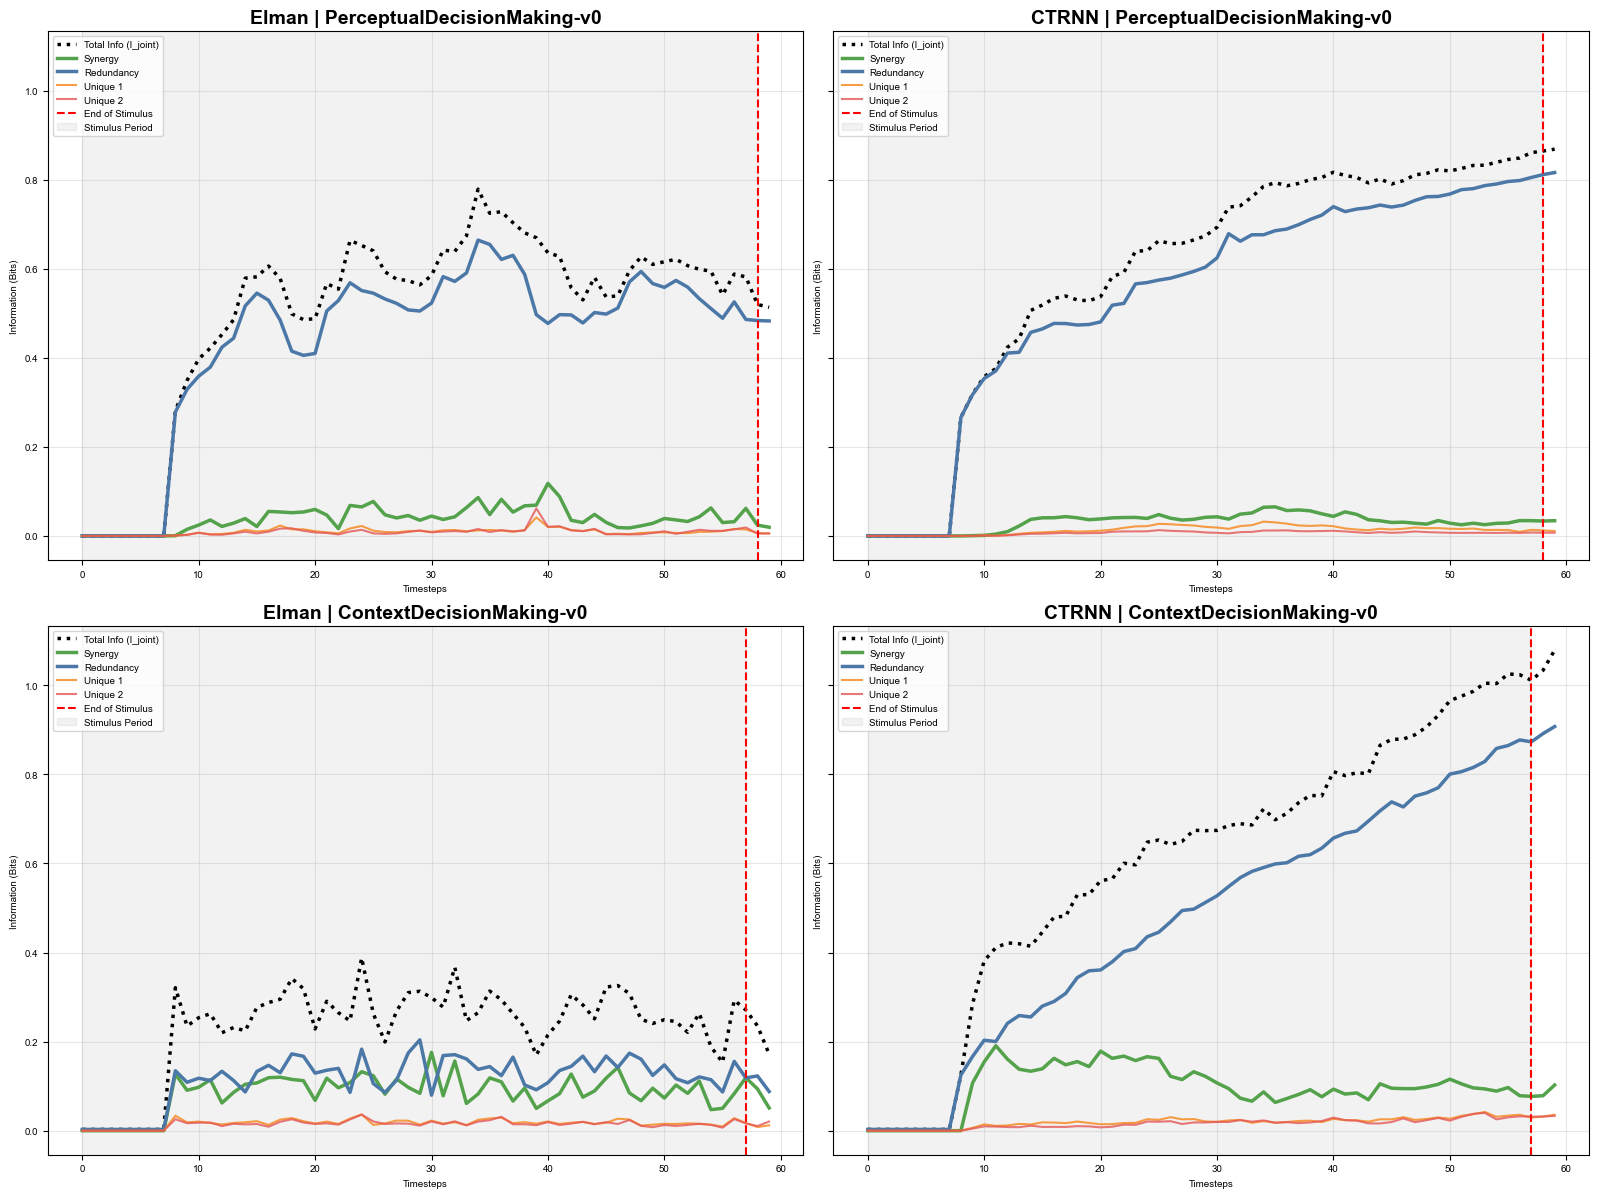

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)

plot_mapping = {
    'Elman_PerceptualDecisionMaking-v0': axes[0, 0],
    'CTRNN_PerceptualDecisionMaking-v0': axes[0, 1],
    'Elman_ContextDecisionMaking-v0':    axes[1, 0],
    'CTRNN_ContextDecisionMaking-v0':    axes[1, 1],
}

for key, ax in plot_mapping.items():
    res = pid_results[key]
    data = res['data']
    time_axis = np.arange(res['seq_len'])
    
    # Plot Total Information (The actual capacity of the network)
    ax.plot(time_axis, data['mi_joint'], label='Total Info (I_joint)', color='black', linestyle=':', linewidth=2.5)
    
    # Plot the 4 PID Atoms
    ax.plot(time_axis, data['synergy'], label='Synergy', color='#54A24B', linewidth=2.5)
    ax.plot(time_axis, data['redundancy'], label='Redundancy', color='#4C78A8', linewidth=2.5)
    ax.plot(time_axis, data['unique1'], label='Unique 1', color='#F58518', linewidth=1.5, alpha=0.8)
    ax.plot(time_axis, data['unique2'], label='Unique 2', color='#E45756', linewidth=1.5, alpha=0.8)
    
    # Mark the End of Stimulus (The proposed snapshot)
    ax.axvline(res['stim_end'], color='red', linestyle='--', label='End of Stimulus')
    ax.axvspan(0, res['stim_end'], color='gray', alpha=0.1, label='Stimulus Period')
    
    ax.set_title(key.replace('_', ' | '), fontsize=14, fontweight='bold')
    ax.set_ylabel('Information (Bits)')
    ax.set_xlabel('Timesteps')
    
    # Move legend outside to prevent covering the data
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()